# Fitting and evaluating a classifier

Let's try to predict the genre of a song by the chords in it. We'll use our chordonomicon data to do this.

#### Installation

In [1]:
# pip install matplotlib numpy pandas seaborn scikit-learn

#### Code

In [2]:
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc, roc_auc_score, make_scorer, accuracy_score, precision_score, recall_score
from sklearn.model_selection import cross_validate
import csv


In [3]:
df = pd.read_csv("hf://datasets/ailsntua/Chordonomicon/chordonomicon_v2.csv")
print(len(df))


df.head()

/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_34339/808363210.py:1: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hf://datasets/ailsntua/Chordonomicon/chordonomicon_v2.csv")


679807


,id,chords,release_date,genres,decade,rock_genre,artist_id,main_genre,spotify_song_id,spotify_artist_id
0,1,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F...,NaN,'classic country pop',NaN,NaN,artist_1,pop,NaN,4AIEGdwDzPELXYgM5JaEY5
1,2,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs...,2003-01-01,'alternative metal' 'alternative rock' 'nu met...,2000.0,pop rock,artist_2,metal,2ffJZ2r8HxI5DHcmf3BO6c,694QW15WkebjcrWgQHzRYF
2,3,<intro_1> Csmin <verse_1> A Csmin A Csmin A Cs...,2003-01-01,'alternative metal' 'canadian rock' 'funk meta...,2000.0,canadian rock,artist_3,metal,5KiY8SZEnvCPyIEkFGRR3y,0niJkG4tKkne3zwr7I8n9n
3,4,<intro_1> D Dmaj7 D Dmaj7 <verse_1> Emin A D G...,2022-09-23,NaN,2020.0,NaN,artist_4,NaN,01TtAcUqyLCRBZq4ZZiQWS,17BfKBemmMGO5ZAK25wraW
4,5,<intro_1> C <verse_1> G C G C <chorus_1> F Dmi...,2023-02-10,'modern country pop',2020.0,NaN,artist_5,pop,3zUecdrWC3IqrNSjhnoF3G,4GGfAshSkqoxpZdoaHm7ky


In [4]:
df.main_genre.value_counts()

main_genre
pop            85185
rock           67238
country        53306
alternative    47252
pop rock       39557
punk           16066
metal          11315
rap            11186
soul            7350
jazz            7001
reggae          3841
electronic      2814
Name: count, dtype: int64

From our earlier Week 3 notebook, we had cleaned up some of the text in it. Here we redo that analysis to get those columns.

Let's filter our songs to those that are either rock or country.

In [5]:
df['is_rock'] = df.main_genre == 'rock'
df['is_country'] = df.main_genre == 'country'

pd.crosstab(df.is_rock, df.is_country)

is_country,False,True
is_rock,,
False,559263,53306
True,67238,0


It's worth keeping in mind that we're already dropping a lot of songs if we exclude ones that are neither rock nor country.

In [6]:
df_rock_or_country = df[df.is_rock | df.is_country]

print(f"{len(df_rock_or_country)/len(df):.2%} of songs in chordonomicon are rock or country.")

17.73% of songs in chordonomicon are rock or country.


## Feature engineering

There are many ways we can turn the chord data into features. Can you think of any?

Here we're going to discard the order information from the chord progressions and view it as a **bag of chords**. That is, we have a statistical picture of how many times each chord shows up in each song. However, as we saw in Week 3, there is a long tail of chords, so let's simply group them into the most common, and then "Other".

In [ ]:
df_rock_or_country['chords_split'] = df_rock_or_country.chords.str.split()
all_chords = df_rock_or_country['chords_split'].explode()
all_chords

<intro_1>
D
G
D
G
D
G
D
G
D
G
D
Bb
C
D
G
D
Bb
C
D
<verse_1>
G
D
Bb
C
D
G
D
Bb
C
G
D
G
D
Bb
C
D
G
D
Bb
C
D
<chorus_1>
C
G
C
A
D
C
<interlude_1>
D
G
D
Bb
C
D
G
D
Bb
C
D
<verse_2>
G
D
Bb
C
D
G
D
Bb
C
D
G
D
Bb
C
D
G
D
Bb
C
D
<chorus_2>
C
G
C
A
D
<interlude_2>
A
D
A
D
A
C
D
<outro_1>
G
D
Bb
C
D
G
D
Bb
C
D
G
D
Bb
C
D
G
D
Bb
C
D
G
D
G
D
Bb
C
D
G
D
Bb
C
D


/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_34339/260280547.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rock_or_country['chords_split'] = df_rock_or_country.chords.str.split()


In [82]:
# this cell illustrates the issue with the tf-idf approach
# below we demonstrate using a very small example
# as we can see the issue is that we are working 
# all_chords_test_theory is engineered the same way as all_chords but with 2 songs
# the issue is we are summing the number of times each chord appears in the entire corpus
# instead we should sum the number of times each chord appears in the 2 songs
pd.set_option('display.max_columns', None) 
df_test = df_rock_or_country.head(2)
all_chords_test_theory = df_test['chords_split'].explode()

test_theory = all_chords_test_theory[~all_chords_test_theory.str.startswith("<")] # Remove the stuff like <intro>
test_theory_chord_frequencies = all_chords_test_theory.value_counts() # this is incorrect
print(test_theory_chord_frequencies)
correct_approach = (test_theory_chord_frequencies > 0).sum(axis=0)
correct_approach
print(correct_approach)


chords_split
G                54
C                50
D                48
F                25
Bb               18
Amin             16
A                 5
<intro_1>         2
<verse_1>         2
<verse_2>         2
<chorus_1>        2
<chorus_2>        2
<interlude_1>     1
<outro_1>         1
<interlude_2>     1
<verse_3>         1
<chorus_3>        1
Name: count, dtype: int64
17


In [8]:
all_chords = all_chords[~all_chords.str.startswith("<")] # Remove the stuff like <intro>
chord_frequencies = all_chords.value_counts()

chord_frequencies

chords_split
G            1359834
C            1091991
D            1046070
A             769027
F             586173
              ...   
Eb7/A              1
Caug/Cs            1
Cdim/C             1
Dbmaj7/Bb          1
Fmin9/G            1
Name: count, Length: 2355, dtype: int64

In [9]:
print(f"The top 30 accounts for {sum(chord_frequencies[:30]) / sum(chord_frequencies):.1%} of all chords.")

top_chords = set(chord_frequencies[:30].index)

chord_frequencies[:30]

The top 30 accounts for 88.4% of all chords.


chords_split
G        1359834
C        1091991
D        1046070
A         769027
F         586173
E         490464
Amin      449583
Emin      409193
Bmin      220802
B         216068
Dmin      180449
Bb        156428
Fsmin     126365
Fs         96468
Csmin      79949
Gmin       70882
Eb         64460
D7         60574
A7         60414
G7         56163
E7         50322
Cmin       47774
B7         47017
Emin7      44801
Cadd9      44476
Ab         43728
Cs         41873
Amin7      40907
Gsmin      36830
Gs         33807
Name: count, dtype: int64

Now, every time that a chord shows up in a song, we're going to count the number of times the top 30 showed up in it. More precisely, we're going to compute the _tf-idf_ of the chord. Essentially we're treating a song as a text, and the chords as the words making up that text, so we're borrowing a technique from natural-language processing to make sense of it.

The _tf-idf_ is the term-frequency (how often a chord appears) moderated by the inverse-document frequency (more rare chords are weighted more highly).

Term frequency is the count of how many times a word appears in a corpus but normalized: number of times a word appears / total words in doc. Think of IDF as a mechanizm for penalizing words that appear in many documents. IDF = log(total docs / docs containing word).

In order to simplify the analysis, I've only included the top 30 chords, and grouped the rest into "other".

In [10]:
from collections import defaultdict

def top_30_counts_vs_other(chords_in_song):
    chord_counts = defaultdict(int) # This is a dictionary that assigns 0 to every unknown key by default

    for chord in chords_in_song:
        if chord.startswith("<"):
            continue # not a chord
        
        if chord in top_chords:
            chord_counts[chord] += 1

        else:
            chord_counts["other"] += 1

    return chord_counts

In [30]:
X_counts = df_rock_or_country['chords_split'].apply(top_30_counts_vs_other).apply(pd.Series)

print(X_counts.shape)
print(X_counts.count())

X_counts = X_counts.fillna(0)

# X_counts.head()
# X_counts.info()

(120544, 31)
D        67412
G        80892
Bb       14297
C        67717
A        52293
F        42668
Amin     38436
Cadd9     3130
E        37753
other    51548
Csmin     8969
B        20872
E7        8257
Dmin     18752
Fsmin    14602
Emin7     5600
Bmin     23904
G7        8266
A7        9626
Emin     37812
Amin7     5618
Ab        4384
B7        7082
Gs        4607
Cs        5397
Fs       11220
Gmin      8059
Eb        6363
Cmin      5665
D7        9862
Gsmin     4457
dtype: int64


In [ ]:
X_term_frequencies = X_counts.div(X_counts.sum(axis=1), axis=0)

X_term_frequencies.head()

,D,G,Bb,C,A,F,Amin,Cadd9,E,other,...,Ab,B7,Gs,Cs,Fs,Gmin,Eb,Cmin,D7,Gsmin
12,0.396694,0.214876,0.14876,0.198347,0.041322,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,0.000000,0.294737,0.00000,0.273684,0.000000,0.263158,0.168421,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.086207,0.500000,0.00000,0.068966,0.000000,0.000000,0.000000,0.344828,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,0.027523,0.000000,0.00000,0.000000,0.284404,0.000000,0.000000,0.000000,0.229358,0.082569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,0.115385,0.000000,0.00000,0.000000,0.173077,0.000000,0.000000,0.000000,0.000000,0.576923,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
X_term_frequencies_log = np.log(1 + X_term_frequencies)
X_term_frequencies_log.head()

,D,G,Bb,C,A,F,Amin,Cadd9,E,other,...,Ab,B7,Gs,Cs,Fs,Gmin,Eb,Cmin,D7,Gsmin
12,0.334108,0.194642,0.138683,0.180943,0.040491,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,0.000000,0.258307,0.000000,0.241914,0.000000,0.233615,0.155653,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.082692,0.405465,0.000000,0.066691,0.000000,0.000000,0.000000,0.296266,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,0.027151,0.000000,0.000000,0.000000,0.250295,0.000000,0.000000,0.000000,0.206492,0.079337,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,0.109199,0.000000,0.000000,0.000000,0.159630,0.000000,0.000000,0.000000,0.000000,0.455476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
top_chords_with_counts = chord_frequencies[:30]
top_chords_with_counts['other'] = sum(chord_frequencies[30:])

top_chords_with_counts

1048402

In [ ]:
# idf_by_chord = np.log(sum(top_chords_with_counts) / top_chords_with_counts)
# each entry is the total number of times that chord appears in the entire corpus, not the number of songs containing that chord
# top_chords_with_counts
idf_by_chord = np.log(sum(top_chords_with_counts) / (X_counts > 0).sum(axis=0))

# idf_by_chord

chords_split
G        1359834
C        1091991
D        1046070
A         769027
F         586173
E         490464
Amin      449583
Emin      409193
Bmin      220802
B         216068
Dmin      180449
Bb        156428
Fsmin     126365
Fs         96468
Csmin      79949
Gmin       70882
Eb         64460
D7         60574
A7         60414
G7         56163
E7         50322
Cmin       47774
B7         47017
Emin7      44801
Cadd9      44476
Ab         43728
Cs         41873
Amin7      40907
Gsmin      36830
Gs         33807
other    1048402
Name: count, dtype: int64

In [28]:
(X_counts > 0).sum(axis=0)

D        67412
G        80892
Bb       14297
C        67717
A        52293
F        42668
Amin     38436
Cadd9     3130
E        37753
other    51548
Csmin     8969
B        20872
E7        8257
Dmin     18752
Fsmin    14602
Emin7     5600
Bmin     23904
G7        8266
A7        9626
Emin     37812
Amin7     5618
Ab        4384
B7        7082
Gs        4607
Cs        5397
Fs       11220
Gmin      8059
Eb        6363
Cmin      5665
D7        9862
Gsmin     4457
dtype: int64

In [16]:
X_tf_idf_chords = X_term_frequencies_log.mul(idf_by_chord, axis=1)

X_tf_idf_chords.head()

,A,A7,Ab,Amin,Amin7,B,B7,Bb,Bmin,C,...,Emin7,F,Fs,Fsmin,G,G7,Gmin,Gs,Gsmin,other
12,0.099922,0.0,0.0,0.000000,0.0,0.00000,0.0,0.563093,0.0,0.383077,...,0.0,0.000000,0.0,0.000000,0.369382,0.0,0.0,0.0,0.0,0.000000
17,0.000000,0.0,0.0,0.467668,0.0,0.00000,0.0,0.000000,0.0,0.512158,...,0.0,0.639931,0.0,0.000000,0.490204,0.0,0.0,0.0,0.0,0.000000
20,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.141193,...,0.0,0.000000,0.0,0.000000,0.769472,0.0,0.0,0.0,0.0,0.000000
21,0.617663,0.0,0.0,0.000000,0.0,0.93542,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.171197
41,0.393926,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.161291,0.000000,0.0,0.0,0.0,0.0,0.982847


### Fitting the classifier

In [17]:
X = X_tf_idf_chords.values
Y = df_rock_or_country.is_rock

logistic_regression_model = LogisticRegression(penalty=None) # WARNING! Scikit-learn's logisticregression does the highly unusual thing of including l2 regularization by default...

logistic_regression_model.fit(X, Y)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
Y

12         True
17         True
20        False
21        False
41         True
          ...  
642852    False
642853    False
642854    False
642855     True
642859    False
Name: is_rock, Length: 120544, dtype: bool

In [ ]:
predicted_on_training = logistic_regression_model.predict(X)

In [ ]:
print(f"""The training accuracy is {np.mean(predicted_on_training == Y):.2%}.
The training precision is {np.mean(Y[predicted_on_training == 1]):.2%}.
The training recall is {np.mean(predicted_on_training[Y == 1]):.2%}.""")

The training accuracy is 63.85%.
The training precision is 65.71%.
The training recall is 73.60%.


In [ ]:
print(f"""The baseline of just guessing "rock" on every entry would yield an accuracy of {np.mean(Y):.2%}""")

The baseline of just guessing "rock" on every entry would yield an accuracy of 55.78%


As we know, in-sample training doesn't give us the full story... the homework now asks you to perform cross-validation to get a better sense of _out-of-sample_ performance.

# Add cells for homework below here

Remember, write out explanations using full sentences in markdown cells. Please don't just submit code without context, I'm a human, not a Python interpreter!

# Understanding the task:
- `X` contains a row for each song and each column contains a chord's TF-IDF score - The data to fit.
- `Y` contains `True` for Rock songs - The target variable to try to predict in the case of supervised learning

Use scikit-learn's `cross_validate` function to generate accuracy, precision, and recall scores. Setting `cv=None` uses the default 5-fold cross validations
resulting in a Train: 80.00%, Test: 20.00% split.

## Question 2(a)
Add a section to the code computing accuracy, prediction, and recall on 5-fold
cross-validation. Put the results into a table and a figure.

In [ ]:
cv_results = cross_validate(
    logistic_regression_model, 
    X, 
    Y,
    cv=None, # a model is trained using k-1 of the folds as training data
    scoring=['accuracy', 'precision', 'recall'],
    return_train_score=False
)

results_df = pd.DataFrame({
    'fold': range(1, 6),
    'accuracy': cv_results['test_accuracy'],
    'precision': cv_results['test_precision'],
    'recall': cv_results['test_recall']
})
results_df


,fold,accuracy,precision,recall
0,1,0.636194,0.651526,0.747695
1,2,0.630014,0.643764,0.753867
2,3,0.639471,0.661791,0.723305
3,4,0.644282,0.667216,0.722689
4,5,0.636677,0.656329,0.731836


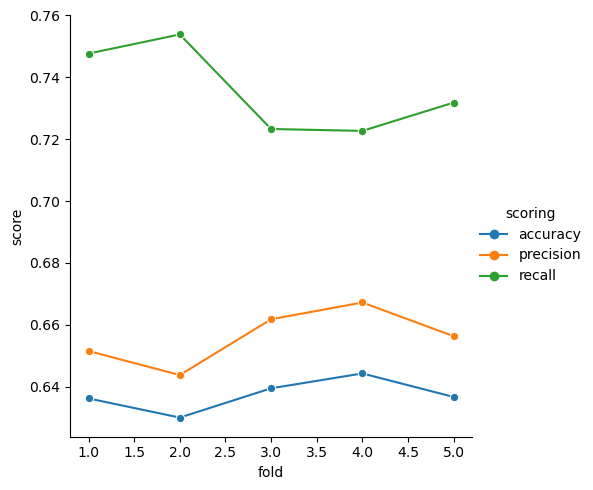

In [ ]:
# https://pandas.pydata.org/docs/reference/api/pandas.melt.html
results_melt = results_df.melt(id_vars=["fold"], var_name="scoring", value_name="score")
sns.relplot(data=results_melt, x="fold", y="score", marker="o", hue="scoring", kind="line")
plt.savefig("plots/rock_v_country_cv", dpi=300, bbox_inches='tight')

## 2(b)
Alternatively, I compute uncertainty for the ROC curves like in this example: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html
The below is essentially plug and play.

Training sizes: [96435, 96435, 96435, 96435, 96436]
Test sizes: [24109, 24109, 24109, 24109, 24108]
Average train size: 96435
Average test size: 24109
Train: 80.00%, Test: 20.00%


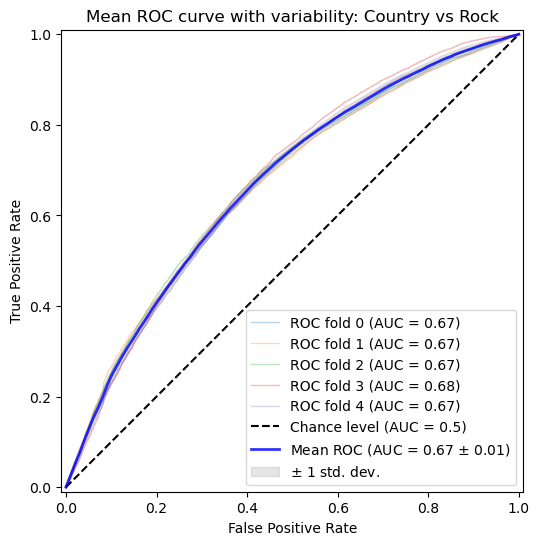

In [ ]:
# The below code is taken from this example: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html
# and adapted for this assignment
cv_results_with_roc = cross_validate(
    logistic_regression_model, 
    X, 
    Y,
    cv=None,
    return_estimator=True,
    return_indices=True,
    scoring=['accuracy', 'precision', 'recall'],
    return_train_score=True
)

# Verifying documentation :) Setting cv=None, to use the default 5-fold cross validation
# In doing so I expect my train and test size to be 80/20
train_sizes = [len(train_idx) for train_idx in cv_results_with_roc['indices']['train']]
test_sizes = [len(test_idx) for test_idx in cv_results_with_roc['indices']['test']]

print("Training sizes:", train_sizes)
print("Test sizes:", test_sizes)

print(f"Average train size: {np.mean(train_sizes):.0f}")
print(f"Average test size: {np.mean(test_sizes):.0f}")

n_folds = len(cv_results_with_roc['test_accuracy'])  # Change this line!
test_pct = (1 / n_folds) * 100
train_pct = 100 - test_pct

print(f"Train: {train_pct:.2f}%, Test: {test_pct:.2f}%")

# RocCurveDisplay.from_cv_results(cv_results_with_roc, X, Y)

n_splits = 5
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
curve_kwargs_list = [
    dict(alpha=0.3, lw=1, color=colors[fold % len(colors)]) for fold in range(n_splits)
]
names = [f"ROC fold {idx}" for idx in range(n_splits)]

mean_fpr = np.linspace(0, 1, 100)
interp_tprs = []

_, ax = plt.subplots(figsize=(6, 6))
viz = RocCurveDisplay.from_cv_results(
    cv_results_with_roc,
    X,
    Y,
    ax=ax,
    name=names,
    curve_kwargs=curve_kwargs_list,
    plot_chance_level=True,
)

for idx in range(n_splits):
    interp_tpr = np.interp(mean_fpr, viz.fpr[idx], viz.tpr[idx])
    interp_tpr[0] = 0.0
    interp_tprs.append(interp_tpr)

mean_tpr = np.mean(interp_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(viz.roc_auc)

ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(interp_tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability: Country vs Rock",
)
ax.legend(loc="lower right")
plt.savefig("plots/cv_results_with_roc", dpi=300, bbox_inches='tight')
plt.show()

## 2(c)
For the above, we only compared rock and country. Now, repeat this classification for every pair of the 12 main genres. This will result in training and evaluating 66 classifiers.

To accomplish this:
- generate an array of tuples containing each of the 66 genre pairs: `genre_pairs`
- create a function that generalizes the initial setup for the first exercise: `generate_genre_pairs`
- loop over `genre_pairs` and use `generate_xy_pairs` (generalizes the country vs rock process) to generate `X` and `Y` pairs: `X_Y_pairs` to feed into `cross_validate`

In [ ]:
##Define the datasets to apply classifiers
from itertools import combinations
all_genres = df['main_genre'][df['main_genre'].isna()==False].unique()
genre_pairs = list(combinations(all_genres,2)) 
X_Y_pairs = {}
def top_30_counts_vs_other_pair(chords_in_song, top_chords_set):
    """
    Count chords using a specific top 30 set for this genre pair
    Attribution to J. Franco for this function
    """
    chord_counts = defaultdict(int)
    
    for chord in chords_in_song:
        if chord.startswith("<"):
            continue  # Skip section markers
        
        if chord in top_chords_set:
            chord_counts[chord] += 1
        else:
            chord_counts["other"] += 1
    
    return chord_counts


def generate_xy_pairs(genre_1, genre_2):
    """
    Compute pair-specific top 30 chords and TF-IDF features
    """
    df_pair = df[(df['main_genre'] == genre_1) | (df['main_genre'] == genre_2)].copy()
    is_genre_1 = df_pair['main_genre'] == genre_1
    
    df_pair['chords_split'] = df_pair['chords'].str.split()
    
    # get top 30 chords for pair
    all_chords_pair = df_pair['chords_split'].explode()
    all_chords_pair = all_chords_pair[~all_chords_pair.str.startswith("<")]
    chord_frequencies_pair = all_chords_pair.value_counts()
    
    top_chords_set = set(chord_frequencies_pair[:30].index)
    
    # same as X_tf_idf_chords above
    X_counts = df_pair['chords_split'].apply(
        lambda chords: top_30_counts_vs_other_pair(chords, top_chords_set)
    ).apply(pd.Series)
    X_counts = X_counts.fillna(0)
    
    # Term frequencies
    X_term_freq = X_counts.div(X_counts.sum(axis=1), axis=0)
    
    # Log scaling like above: X_term_frequencies_log = np.log(1 + X_term_frequencies)
    X_term_freq_log = np.log(1 + X_term_freq)
    
    # Document-based IDF (J. Franco's advice - confirmed with Sam)
    idf_pair = np.log(X_term_freq.shape[0] / (X_term_freq_log != 0).sum(axis=0))
    
    # TF-IDF
    X_tf_idf = X_term_freq_log.mul(idf_pair, axis=1).fillna(0)
    
    return X_tf_idf, is_genre_1

for genre_1, genre_2 in genre_pairs:
    X, y = generate_xy_pairs(genre_1, genre_2)
    X_Y_pairs[(genre_1, genre_2)] = (X, y)


In [ ]:

cv_results_all = {}

# use a custom scoring dictionary with AUC-ROC as the metric
scoring = {
    'auc': make_scorer(roc_auc_score),
}

for (genre_1, genre_2), (X, y) in X_Y_pairs.items():    
    logistic_regression_model = LogisticRegression(penalty=None, max_iter=1000)

    cv_results = cross_validate(
        logistic_regression_model,
        X,
        y,
        cv=None,
        return_estimator=True,
        return_indices=True,
        scoring=scoring,
        return_train_score=True
    )
    
    cv_results_all[(genre_1, genre_2)] = cv_results    

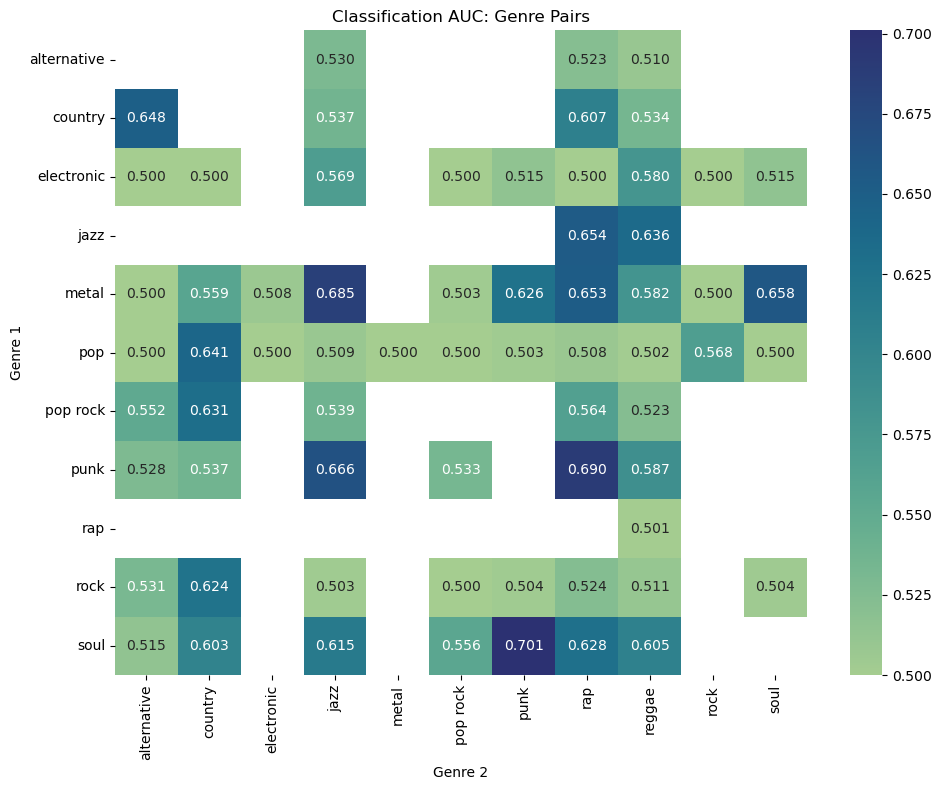

In [ ]:
summary_results = []

for (genre_1, genre_2), cv_results in cv_results_all.items():
    summary_results.append({
        'genre_1': genre_1,
        'genre_2': genre_2,
        'mean_test_auc': cv_results['test_auc'].mean(), 
    })

summary_df = pd.DataFrame(summary_results)

heatmap_data = summary_df.pivot(
    index='genre_1', 
    columns='genre_2', 
    values='mean_test_auc'
)

# display values for writeup purposes
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,
    fmt='.3f',
    cmap='crest',
)
plt.title('Classification AUC: Genre Pairs')
plt.xlabel('Genre 2')
plt.ylabel('Genre 1')
plt.tight_layout()
plt.savefig("plots/auc_all_genres")
plt.show()

In [ ]:
genre_pairs
